<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_3/blob/main/17_4_5_EXTRA_Hugging_Face_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tuning ViT for Image Classification on Bean Leaf Images

In this notebook, we’ll fine-tune a Vision Transformer (ViT) model to classify images of bean leaves into three categories: `healthy`, `angular_leaf_spot`, and `bean_rust`. We’ll use the Hugging Face `transformers` library to set up, train, and evaluate the model, providing an introduction to image classification with transformers.

---

## Task Overview: Image Classification

**Goal**: Fine-tune a Vision Transformer (ViT) model to classify images of bean leaves based on health conditions.

---

## Dataset

- **Dataset**: `beans` dataset from the Hugging Face datasets library.
- **Description**: The Beans dataset contains high-quality images of bean leaves categorized into three classes: `healthy`, `angular_leaf_spot` (a disease causing leaf spots), and `bean_rust` (a fungal infection on leaves). This dataset is relevant for applications in agriculture, enabling us to detect diseases in plants based on visual cues.
- **Purpose**: The dataset provides a clear and visually distinct classification task for the model to learn from. The model can be trained to recognize specific patterns in leaf images, which could later be applied to broader image classification tasks.

---

## Model

- **Model Used**: `google/vit-base-patch16-224`
- **Model Architecture**: Vision Transformer (ViT) is a transformer model adapted for images. Unlike traditional CNNs, ViT divides an image into patches and processes them through transformer layers, leveraging self-attention to model spatial relationships.
- **Fine-Tuning Objective**: Fine-tune ViT for multi-class image classification. By adapting the pre-trained model to the Beans dataset, we aim to achieve high accuracy in classifying the health condition of bean leaves based on image data.

---

## Training and Evaluation Process

1. **Data Preparation**:
   - We load the Beans dataset, which is split into training and validation sets.
   - Using the ViT feature extractor, we preprocess each image by resizing, normalizing, and splitting it into patches suitable for ViT input.

2. **Training**:
   - Training arguments are configured, including settings for batch size, number of epochs, and learning rate.
   - Using Hugging Face’s `Trainer` API, we initialize training, where the model learns to classify the images based on patterns in the data.

3. **Evaluation**:
   - After training, the model is evaluated on the validation set to assess its accuracy and performance.
   - The results will help us understand how well the model generalizes to new images and whether it successfully learned the visual patterns of each class.

---

This notebook illustrates the process of fine-tuning a transformer model for image classification, allowing you to explore Hugging Face’s capabilities in computer vision tasks and to apply the approach to other image classification problems.

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 13.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


### Import Libraries

To start, we import the necessary libraries and load the dataset and train the model.

In [ ]:
from transformers import AutoModelForImageClassification, AutoFeatureExtractor, Trainer, TrainingArguments
from datasets import load_dataset

### Load the dataset

We load the `beans` dataset, which contains images of bean leaves classified into three health conditions: `healthy`, `angular_leaf_spot`, and `bean_rust`. This dataset will be used to fine-tune a Vision Transformer (ViT) model, helping it learn to identify different health conditions based on visual features in the images.

In [ ]:
# Load the beans dataset
dataset = load_dataset("beans")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/144M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/18.5M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

### Preprocess the Images

In this step, we use a ViT feature extractor to preprocess each image in the dataset. The feature extractor resizes, normalizes, and splits each image into patches suitable for ViT’s input structure. This preprocessing is necessary for ensuring that the images are compatible with the Vision Transformer architecture, which operates on patches rather than traditional convolutional filters.


In [ ]:
# Load the feature extractor
feature_extractor = AutoFeatureExtractor.from_pretrained("google/vit-base-patch16-224")

# Preprocess images
def preprocess_images(example):
    inputs = feature_extractor(example["image"], return_tensors="pt")
    inputs["label"] = example["labels"]
    return inputs

# Apply preprocessing
prepared_ds = dataset.map(preprocess_images, batched=True)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


Map:   0%|          | 0/1034 [00:00<?, ? examples/s]

Map:   0%|          | 0/133 [00:00<?, ? examples/s]

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

### Initialize the Model

We initialize a pre-trained Vision Transformer (ViT) model configured for image classification with three classes. The model is adapted for our specific task of classifying bean leaf health conditions.

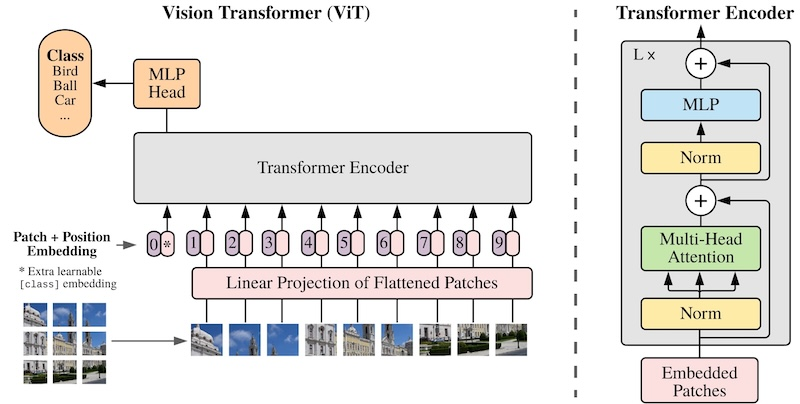

In [ ]:
# Load the model
model = AutoModelForImageClassification.from_pretrained("google/vit-base-patch16-224", num_labels=3, ignore_mismatched_sizes=True)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Model training

We set up training arguments, which control aspects of the training process such as the number of epochs, batch size, and learning rate.

Then, with the `Trainer` API, we initiate the training process on the preprocessed dataset. The Trainer API simplifies the training loop and manages batching, gradient updates, and model optimization, allowing the ViT model to learn visual patterns associated with each class. This step gradually adjusts the model’s parameters to improve classification accuracy.


In [ ]:
# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to="none"
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=prepared_ds["train"],
    eval_dataset=prepared_ds["validation"],
)

# Train the model
trainer.train()

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,No log,0.120504
2,No log,0.085072
3,No log,0.016120


TrainOutput(global_step=390, training_loss=0.0869124290270683, metrics={'train_runtime': 477.5712, 'train_samples_per_second': 6.495, 'train_steps_per_second': 0.817, 'total_flos': 2.4038230623573197e+17, 'train_loss': 0.0869124290270683, 'epoch': 3.0})

### Evaluate the Model

After training, we evaluate the model on the validation set to measure its accuracy in classifying new images. The evaluation results provide insights into the model’s ability to generalize beyond the training data, offering metrics to assess the effectiveness of the fine-tuning process for image classification.

In [ ]:
# Evaluate the model
eval_results = trainer.evaluate()
print(eval_results)

{'eval_loss': 0.016119809821248055, 'eval_runtime': 14.6538, 'eval_samples_per_second': 9.076, 'eval_steps_per_second': 1.16, 'epoch': 3.0}


### Evaluate the Image Classification Model

For the image classification task, we evaluate the fine-tuned Vision Transformer (ViT) model on the validation set. Using `trainer.predict()`, we obtain predictions for each image in the validation set, which allows us to assess the model’s performance without re-training.

We then pass these predictions and the true labels to the `compute_metrics` function, which calculates key metrics such as **accuracy**, **F1 score**, **precision**, and **recall**. These metrics offer insights into how well the model can classify the health conditions of bean leaves, helping us understand its generalization capability and suitability for practical applications.

- `trainer.predict()` generates predictions on the validation set.
- The output is processed by `compute_metrics`, which calculates important metrics.
- We print the metrics to gain an understanding of the model’s classification accuracy on new images.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Define the custom metrics function
def compute_metrics(predictions, labels):
    predictions = predictions.argmax(axis=-1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")
    precision = precision_score(labels, predictions, average="weighted")
    recall = recall_score(labels, predictions, average="weighted")
    return {
        "accuracy": accuracy,
        "f1": f1,
        "precision": precision,
        "recall": recall,
    }

# Run predictions on the validation/test set for image classification
predictions_output = trainer.predict(prepared_ds["test"])

# Extract predictions and labels
predictions = predictions_output.predictions
labels = predictions_output.label_ids

# Calculate metrics
metrics = compute_metrics(predictions, labels)
print("Evaluation Metrics for Image Classification:", metrics)

Evaluation Metrics for Image Classification: {'accuracy': 0.9765625, 'f1': 0.97665013502285, 'precision': 0.9769176136363636, 'recall': 0.9765625}
